In [56]:
import numpy as np
import cellrank as cr
import scanpy as sc
import scvelo as scv
import matplotlib as mpl
import matplotlib.pyplot as plt

import json
from datetime import datetime

In [57]:
%config InlineBackend.figure_format = 'retina'

plt.rcParams['figure.figsize'] = (15, 15)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/matplotlib_inline/config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


In [3]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

In [4]:
adata = sc.read_h5ad('data/gut_data/gut_hs_fetal_epithelial_scVI_AM_06032025_145649_raw.h5ad')

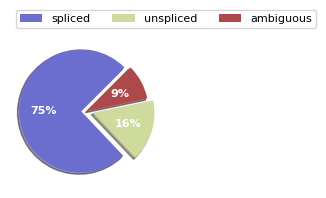

In [5]:
scv.pl.proportions(adata)

In [6]:
scv.pp.filter_and_normalize(
    adata, min_shared_counts=20, n_top_genes=2000, subset_highly_variable=False
)

sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30, random_state=0)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

Filtered out 28191 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


Logarithmized X.


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


computing moments based on connectivities
    finished (0:01:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [7]:
scv.tl.recover_dynamics(adata, n_jobs=8)
scv.tl.velocity(adata, mode="dynamical")

recovering dynamics (using 8/8 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:32:50) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:01:22) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [8]:
vk = cr.kernels.VelocityKernel(adata)
vk.compute_transition_matrix()

100%|██████████████████████████████████████████████████████████████████████████████████████| 71712/71712 [00:14<00:00, 4935.97cell/s]


VelocityKernel[n=71712, model='deterministic', similarity='correlation', softmax_scale=2.501]

## Use pseudotime to recover directed differentiation

In [10]:
sc.tl.diffmap(adata)

In [12]:
adata.obs['cell_states'] = adata.obs['cell_states'].astype('str') + '_' + adata.obs['leiden_cluster'].astype('str')
adata.obs['cell_states'] = adata.obs['cell_states'].str.replace(r'_nan', '', regex=True)
adata.obs['cell_states'] = adata.obs['cell_states'].astype('category')

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

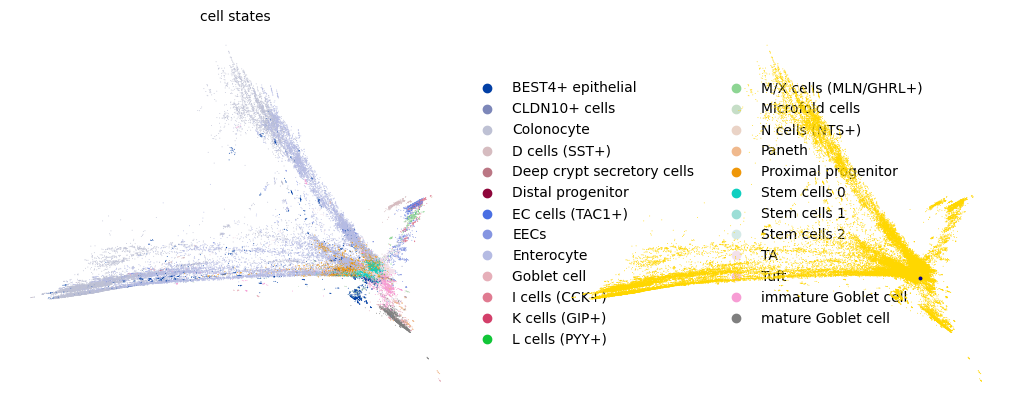

In [39]:
root_ixs = 2394  # has been found using `adata.obsm['X_diffmap'][:, 3].argmax()`
scv.pl.scatter(
    adata,
    basis="diffmap",
    c=["cell_states", root_ixs],
    legend_loc="right",
    components=["2, 4"],
)

adata.uns["iroot"] = root_ixs

In [ ]:
fig = plt.figure(figsize=(5, 5), dpi=180)

sc.tl.dpt(adata)
sc.pl.embedding(
    adata,
    basis="umap",
    color=["dpt_pseudotime"],
    color_map="gnuplot2",
)

plt.tight_layout()

plt.savefig('figures/dpt_pseudotime.png', dpi=180, bbox_inches='tight')
plt.show()

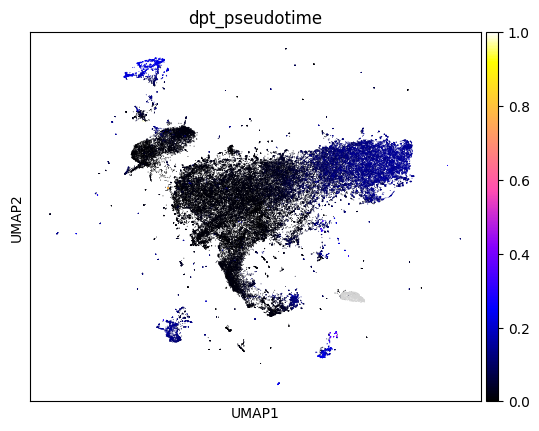

In [41]:
sc.tl.dpt(adata)
sc.pl.embedding(
    adata,
    basis="umap",
    color=["dpt_pseudotime"],
    color_map="gnuplot2",
)


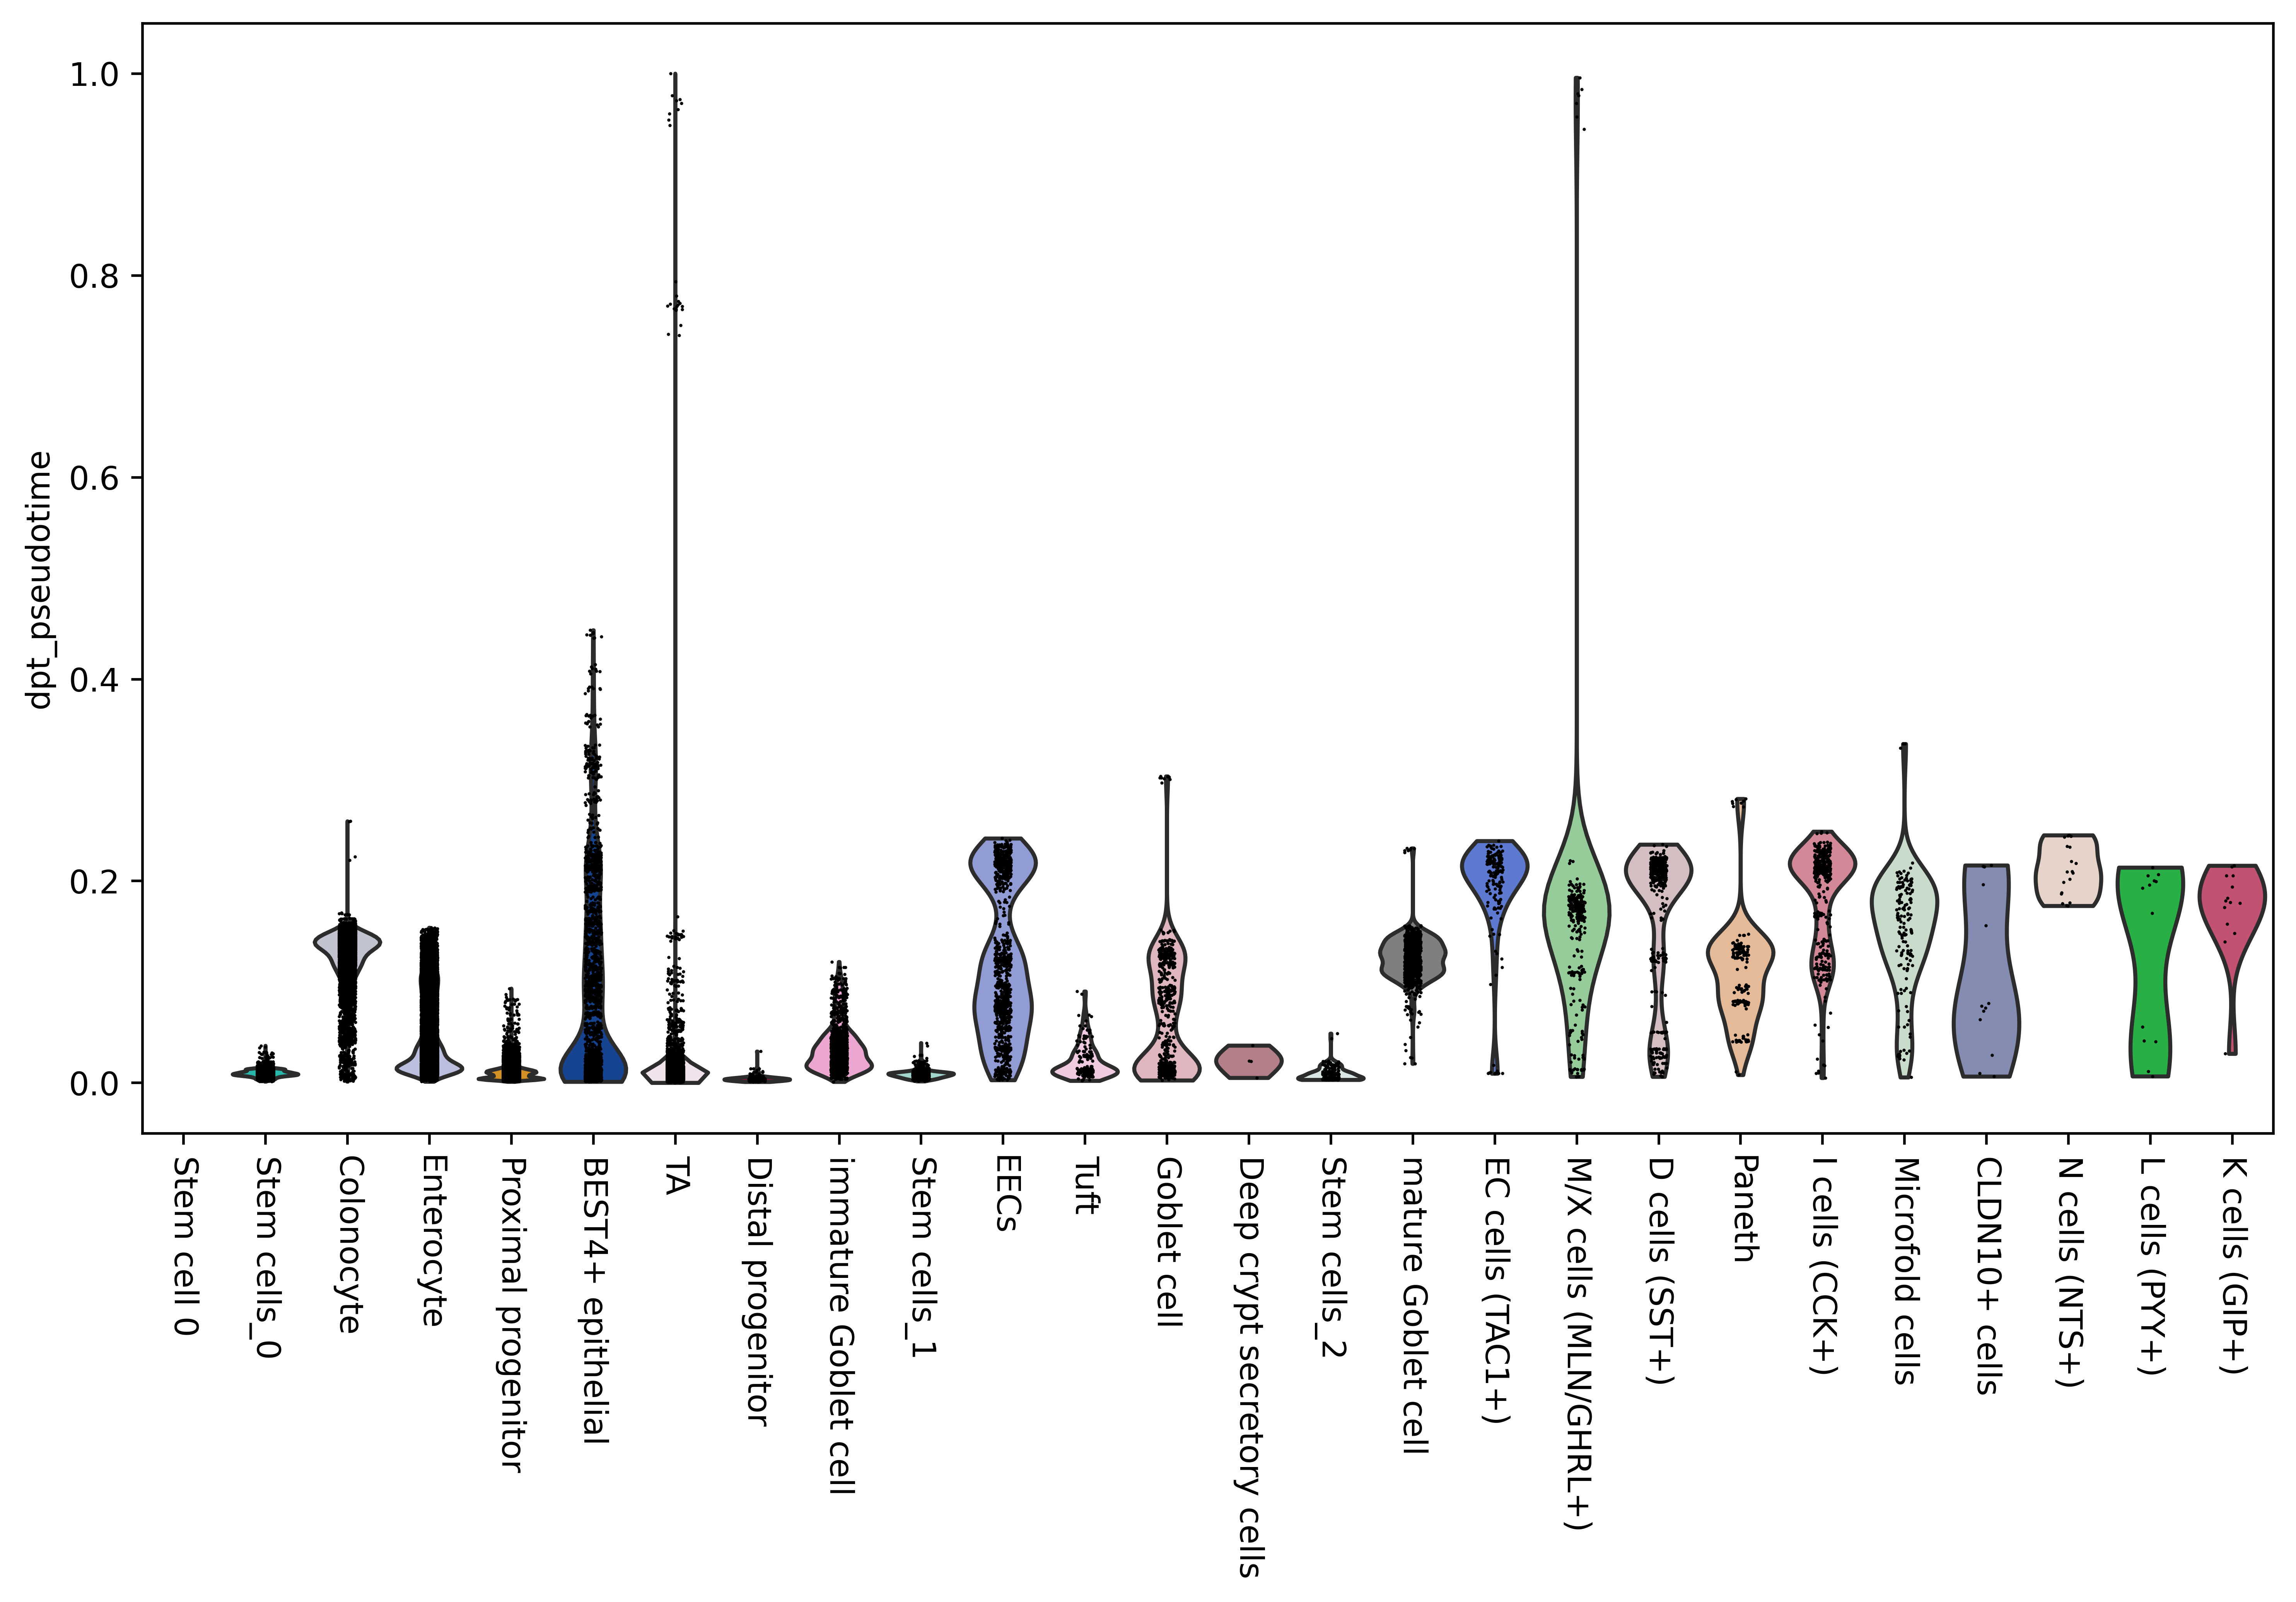

In [72]:
all_trajectory = ["Stem cell 0"] + [cluster for cluster in adata.obs["cell_states"].unique() if cluster != "Stem cell_0"]

fig = plt.figure(figsize=(10, 7), dpi=300)

sc.pl.violin(
    adata,  
    keys=["dpt_pseudotime"],
    groupby="cell_states",
    rotation=-90,
    order=all_trajectory,
    show=False,
    ax=plt.gca()  # Use the current axis from the high-res figure
)

plt.tight_layout()

plt.savefig('figures/pseudotime_trajectory_sc0.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
all_trajectory = ["Stem cell 0", "TA", "Enterocyte", "BEST4+ epithelial", "Colonocyte"]
mask = np.in1d(adata.obs["cell_states"], all_trajectory)

fig = plt.figure(figsize=(1, 3), dpi=300)
sc.pl.violin(
    adata[mask],
    keys=["dpt_pseudotime"],
    groupby="cell_states",
    rotation=-90,
    order=all_trajectory,
)
plt.tight_layout()
plt.savefig('figures/pseudotime_trajectory_sc0_and_absorptive.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
all_trajectory = ["Stem cell 1", "TA", "Enterocyte", "BEST4+ epithelial", "Colonocyte"]
mask = np.in1d(adata.obs["cell_states"], all_trajectory)

fig = plt.figure(figsize=(1, 3), dpi=300)
sc.pl.violin(
    adata[mask],
    keys=["dpt_pseudotime"],
    groupby="cell_states",
    rotation=-90,
    order=all_trajectory,
)
plt.tight_layout()
plt.savefig('figures/pseudotime_trajectory_sc1_and_absorptive.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
all_trajectory = ["Stem cell 2", "TA", "Enterocyte", "BEST4+ epithelial", "Colonocyte"]
mask = np.in1d(adata.obs["cell_states"], all_trajectory)

fig = plt.figure(figsize=(1, 3), dpi=300)
sc.pl.violin(
    adata[mask],
    keys=["dpt_pseudotime"],
    groupby="cell_states",
    rotation=-90,
    order=all_trajectory,
)
plt.tight_layout()
plt.savefig('figures/pseudotime_trajectory_sc2_and_absorptive.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
all_trajectory = ["Stem cell 0", "TA", "immature Goblet cell", "mature Goblet cell", "Goblet cell", "Paneth", "Microfold cells", "EECs", "EC cells (TAC1+)", "D cells (SST+)", "I cells (CCK+)", "M/X cells (MLN/GHRL+)", "N cells (NTS+)", "K cells (GIP+)", "CLDN10+ cells", "L cells (PYY+)"]
mask = np.in1d(adata.obs["cell_states"], all_trajectory)

fig = plt.figure(figsize=(1, 3), dpi=300)
sc.pl.violin(
    adata[mask],
    keys=["dpt_pseudotime"],
    groupby="cell_states",
    rotation=-90,
    order=all_trajectory,
)
plt.tight_layout()
plt.savefig('figures/pseudotime_trajectory_sc0_and_secretory.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
all_trajectory = ["Stem cell 1", "TA", "immature Goblet cell", "mature Goblet cell", "Goblet cell", "Paneth", "Microfold cells", "EECs", "EC cells (TAC1+)", "D cells (SST+)", "I cells (CCK+)", "M/X cells (MLN/GHRL+)", "N cells (NTS+)", "K cells (GIP+)", "CLDN10+ cells", "L cells (PYY+)"]
mask = np.in1d(adata.obs["cell_states"], all_trajectory)

fig = plt.figure(figsize=(1, 3), dpi=300)
sc.pl.violin(
    adata[mask],
    keys=["dpt_pseudotime"],
    groupby="cell_states",
    rotation=-90,
    order=all_trajectory,
)
plt.tight_layout()
plt.savefig('figures/pseudotime_trajectory_sc1_and_secretory.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
all_trajectory = ["Stem cell 2", "TA", "immature Goblet cell", "mature Goblet cell", "Goblet cell", "Paneth", "Microfold cells", "EECs", "EC cells (TAC1+)", "D cells (SST+)", "I cells (CCK+)", "M/X cells (MLN/GHRL+)", "N cells (NTS+)", "K cells (GIP+)", "CLDN10+ cells", "L cells (PYY+)"]
mask = np.in1d(adata.obs["cell_states"], all_trajectory)

fig = plt.figure(figsize=(1, 3), dpi=300)
sc.pl.violin(
    adata[mask],
    keys=["dpt_pseudotime"],
    groupby="cell_states",
    rotation=-90,
    order=all_trajectory,
)
plt.tight_layout()
plt.savefig('figures/pseudotime_trajectory_sc2_and_secretory.png', dpi=300, bbox_inches='tight')
plt.show()

## Compute a transition matrix

In [79]:
pk = cr.kernels.PseudotimeKernel(adata, time_key="dpt_pseudotime")
pk.compute_transition_matrix()

print(pk)

100%|█████████████████████████████████████████████████████████████████████████████████████| 71712/71712 [00:05<00:00, 12816.26cell/s]


PseudotimeKernel[n=71712]


In [ ]:
pk.plot_projection(
    basis='X_umap',           
    color='cell_states',     
    arrow_size=1.5,      
    density=0.8,         
    figsize=(10, 8),
    legend_loc='on data',
    legend_fontsize=3,
    save="figures/pseudotime_umap_transition_matrix.png",
    dpi= 300
)